# 02: Text Preprocessing & TF-IDF Feature Engineering

**Project Title:** Email Intent Classification with Attention-Based Sequence Models and Priority Prediction  
**Phases Covered:** Phase 2 (Text Preprocessing) & Phase 3 (Train/Val/Test Split + TF-IDF Vectorization)

---

### 🎯 Objectives:
1. Load raw dataset (`data/raw/email_intent_full_raw.csv`).
2. Clean raw text: lowercasing, HTML removal, URL removal, email address removal, special character cleaning, whitespace normalization.
3. Compute summary statistics (original count, rows removed, min/max/mean text length).
4. Save cleaned dataset (`data/processed/cleaned_emails.csv`).
5. Perform 70/15/15 Stratified Train/Validation/Test Split.
6. Build TF-IDF representations (`max_features=5000`, `ngram_range=(1,2)`, `min_df=2`) fitting **ONLY** on the training set.
7. Save TF-IDF vectorizer (`models/tfidf_vectorizer.pkl`).


In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib

sns.set_theme(style="whitegrid")
os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../models", exist_ok=True)
os.makedirs("../results/figures", exist_ok=True)


## 1. Load Raw Dataset

In [2]:
df_raw = pd.read_csv("../data/raw/email_intent_full_raw.csv")
print(f"Original Dataset Shape: {df_raw.shape}")
df_raw.head(3)


Original Dataset Shape: (2533, 5)


,email_text,intent,urgency,order_id,product
0,Subj: Case 0001 - Order 51001 laptop never sho...,delivery_issue,high,51001.0,laptop
1,"Subj: Case 0002 - Hey, order 51002 (router) sa...",delivery_issue,medium,51002.0,router
2,Subj: Case 0003 - Order 51003 monitor arrived ...,delivery_issue,high,51003.0,monitor


## 2. Text Preprocessing & Cleaning

In [3]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'subj:\s*case\s*\d+\s*-\s*', '', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df = df_raw.dropna(subset=['email_text', 'intent']).drop_duplicates(subset=['email_text']).copy()
df['clean_email_text'] = df['email_text'].apply(clean_text)

df['char_length'] = df['clean_email_text'].apply(len)
df['word_count'] = df['clean_email_text'].apply(lambda x: len(x.split()))

print(f"Final Cleaned Dataset Shape: {df.shape}")
print(f"Rows Removed: {len(df_raw) - len(df)}")

print("\n--- Sample Comparison ---")
for i in range(3):
    print(f"Original: {df['email_text'].iloc[i]}")
    print(f"Cleaned:  {df['clean_email_text'].iloc[i]}\n")


Final Cleaned Dataset Shape: (2533, 8)
Rows Removed: 0

--- Sample Comparison ---
Original: Subj: Case 0001 - Order 51001 laptop never showed up, tracking is stuck on 'label created'... pls help asap.
Cleaned:  order 51001 laptop never showed up tracking is stuck on label created pls help asap

Original: Subj: Case 0002 - Hey, order 51002 (router) says delivered but we didnt recieve anything, can you check?
Cleaned:  hey order 51002 router says delivered but we didnt recieve anything can you check

Original: Subj: Case 0003 - Order 51003 monitor arrived but the box is smashed + screen cracked, what now??
Cleaned:  order 51003 monitor arrived but the box is smashed screen cracked what now



## 3. Save Processed Dataset & Generate EDA Visualizations

C:\Users\Vivek wadher\AppData\Local\Temp\ipykernel_5956\97125000.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=intent_counts.values, y=intent_counts.index, palette="viridis")


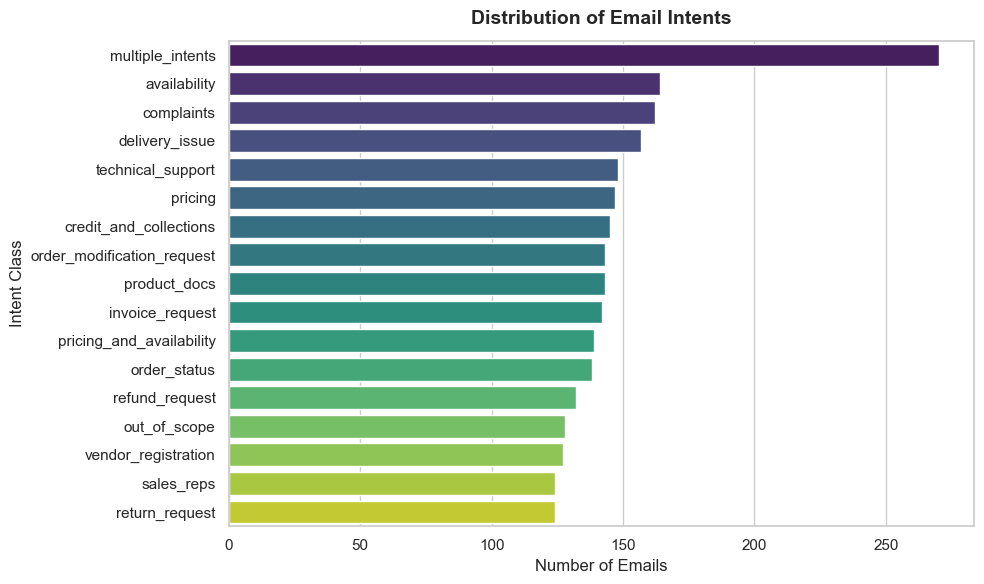

C:\Users\Vivek wadher\AppData\Local\Temp\ipykernel_5956\97125000.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=valid_urgency, order=['low', 'medium', 'high'], palette="mako")


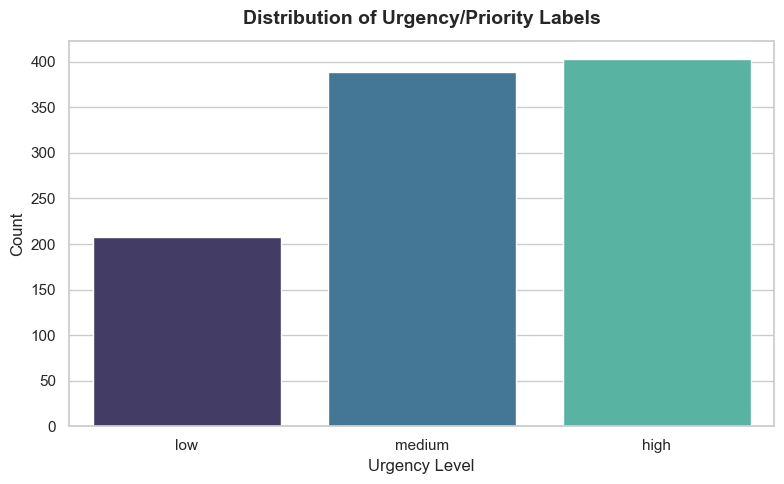

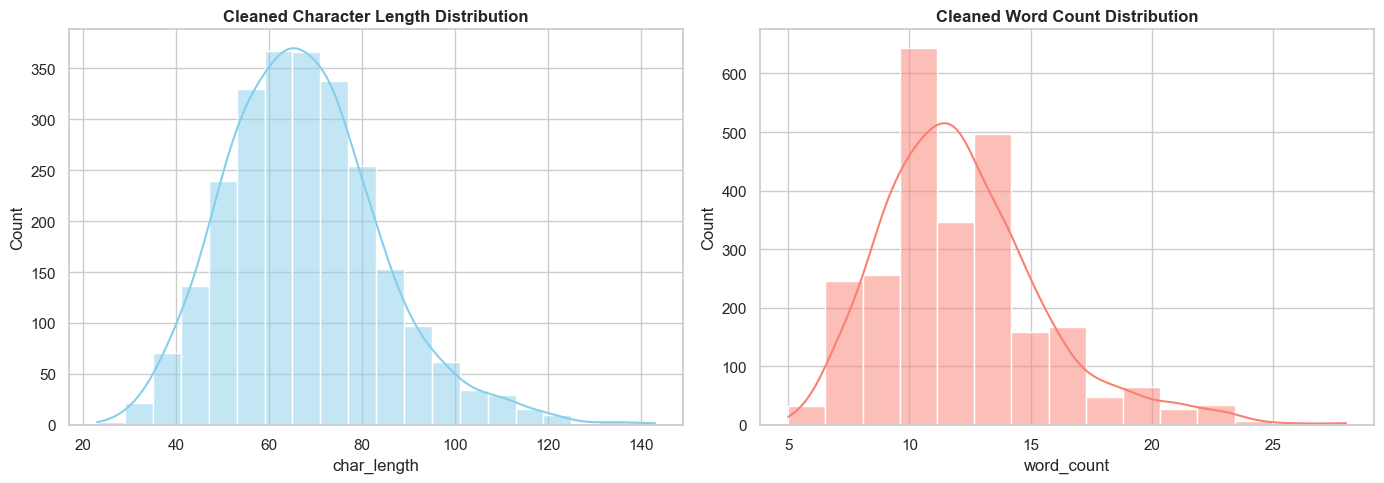

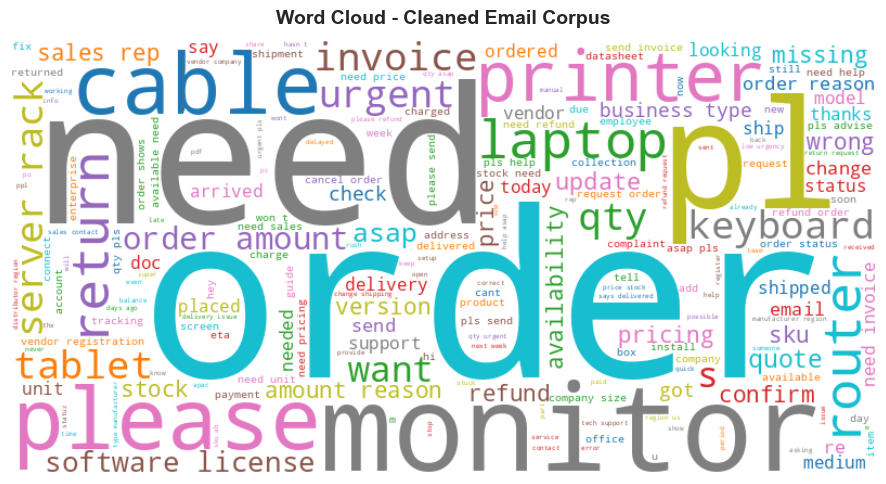

In [4]:
# Save processed dataset
df.to_csv("../data/processed/cleaned_emails.csv", index=False)

# 1. Intent Distribution
plt.figure(figsize=(10, 6))
intent_counts = df['intent'].value_counts()
ax = sns.barplot(x=intent_counts.values, y=intent_counts.index, palette="viridis")
plt.title("Distribution of Email Intents", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("Number of Emails")
plt.ylabel("Intent Class")
plt.tight_layout()
plt.savefig("../results/figures/intent_distribution.png", dpi=300)
plt.show()

# 2. Priority Distribution
plt.figure(figsize=(8, 5))
valid_urgency = df['urgency'].dropna()
ax = sns.countplot(x=valid_urgency, order=['low', 'medium', 'high'], palette="mako")
plt.title("Distribution of Urgency/Priority Labels", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("Urgency Level")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../results/figures/priority_distribution.png", dpi=300)
plt.show()

# 3. Email Length Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['char_length'], kde=True, ax=axes[0], color="skyblue", bins=20)
axes[0].set_title("Cleaned Character Length Distribution", fontsize=12, fontweight='bold')
sns.histplot(df['word_count'], kde=True, ax=axes[1], color="salmon", bins=15)
axes[1].set_title("Cleaned Word Count Distribution", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("../results/figures/email_length_distribution.png", dpi=300)
plt.show()

# 4. Word Cloud
all_text = " ".join(df['clean_email_text'])
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='tab10').generate(all_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud - Cleaned Email Corpus", fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig("../results/figures/wordcloud.png", dpi=300)
plt.show()


## 4. Train / Validation / Test Split (70 / 15 / 15)

In [5]:
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=42, stratify=df['intent'])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df['intent'])

print(f"Train set: {len(train_df)} rows ({len(train_df)/len(df)*100:.1f}%)")
print(f"Val set:   {len(val_df)} rows ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test set:  {len(test_df)} rows ({len(test_df)/len(df)*100:.1f}%)")

train_df.to_csv("../data/processed/train_emails.csv", index=False)
val_df.to_csv("../data/processed/val_emails.csv", index=False)
test_df.to_csv("../data/processed/test_emails.csv", index=False)


Train set: 1773 rows (70.0%)
Val set:   380 rows (15.0%)
Test set:  380 rows (15.0%)


## 5. TF-IDF Feature Engineering

In [6]:
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)

# FIT ONLY ON TRAINING SET to prevent data leakage!
X_train_tfidf = vectorizer.fit_transform(train_df['clean_email_text'])
X_val_tfidf = vectorizer.transform(val_df['clean_email_text'])
X_test_tfidf = vectorizer.transform(test_df['clean_email_text'])

print(f"TF-IDF Vocabulary Size: {len(vectorizer.vocabulary_)} features")
print(f"X_train_tfidf matrix shape: {X_train_tfidf.shape}")
print(f"X_val_tfidf matrix shape:   {X_val_tfidf.shape}")
print(f"X_test_tfidf matrix shape:  {X_test_tfidf.shape}")

# Save Vectorizer
joblib.dump(vectorizer, "../models/tfidf_vectorizer.pkl")
print("Saved TfidfVectorizer to ../models/tfidf_vectorizer.pkl")


TF-IDF Vocabulary Size: 3592 features
X_train_tfidf matrix shape: (1773, 3592)
X_val_tfidf matrix shape:   (380, 3592)
X_test_tfidf matrix shape:  (380, 3592)
Saved TfidfVectorizer to ../models/tfidf_vectorizer.pkl
